# Bước 08: Giải Thích Mô Hình Machine Learning (Explainable AI - SHAP) & Trực Quan Hóa Tương Tác
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers
Nguồn tham chiếu: `srcs/05_machine_learning/Forcasting_v3/12_explain_shap.py`

## 1. Tổng quan
Notebook này thực hiện giải thích cơ chế ra quyết định của mô hình LightGBM chiến thắng thông qua phương pháp SHAP (SHapley Additive exPlanations):
1. **SHAP Global Importance & Beeswarm:** Đánh giá tầm quan trọng tổng thể của các đặc trưng trên toàn tập Test.
2. **Dependency Plots:** Xem xét tác động phi tuyến của các đặc trưng hàng đầu.
3. **Local Explanations (Waterfall):** Giải thích chi tiết các điểm sai số lớn nhất.
4. **Feature Type Importance:** Nhóm đặc trưng theo bản chất (thời gian, thời tiết, lịch sử lag/rolling, trạm).
5. **Trực quan hóa Plotly Tương Tác 42 Trạm:** Biểu đồ đường kéo thả phong to thu nhỏ cho 42 trạm quang điện.
6. **Xuất file:** Ghi kết quả ra `shap_values.parquet` và `shap_importance.csv` để Dashboard sử dụng.

## 2. Import thư viện và khai báo tham số

In [1]:
import gc
import json
import os
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import pyarrow.parquet as pq
import shap

warnings.filterwarnings('ignore')

# ── Tham số chung ──
VERSION = 'v3'
SITE_COL = 'site_id'
TIMESTAMP_COL = 'timestamp'
TARGET_COL = 'energy_generated_kwh'
SEED = 42
SAMPLE_SIZE = 2000

# ── Đường dẫn dữ liệu ──
SELECTED_DIR = '../../data/model/v3/05_selected'
TRAIN_BASE_DIR = '../../data/model/v3/06_train'
TEST_FINAL_DIR = '../../data/model/v3/07_final_test'
OUTPUT_DIR = '../../data/model/v3/08_explain'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Đã import thư viện và khai báo tham số cho Notebook 08.")
print("Kích thước mẫu SHAP :", SAMPLE_SIZE)
print("Thư mục xuất kết quả:", OUTPUT_DIR)

Đã import thư viện và khai báo tham số cho Notebook 08.
Kích thước mẫu SHAP : 2000
Thư mục xuất kết quả: ../../data/model/v3/08_explain


## 3. Nạp mô hình chiến thắng và dữ liệu tập test

In [2]:
# Đọc file best_loss.json để xác định mô hình chiến thắng
best_loss_path = f'{TEST_FINAL_DIR}/best_loss.json'
if not os.path.exists(best_loss_path):
    raise FileNotFoundError(
        "Chưa có file best_loss.json tại: " + best_loss_path + ". "
        "Hãy chạy notebook 07_final_test.ipynb trước!"
    )

with open(best_loss_path, 'r', encoding='utf-8') as f:
    best_loss_data = json.load(f)

# Lấy loss thắng của h1 (hoặc loss thắng chung)
if 'h1' in best_loss_data:
    winning_loss = best_loss_data['h1']['winning_loss']
elif 'winning_loss' in best_loss_data:
    winning_loss = best_loss_data['winning_loss']
else:
    winning_loss = 'mse'

model_dir = f'{TRAIN_BASE_DIR}/{winning_loss}/h1'
if not os.path.exists(f'{model_dir}/model.pkl'):
    model_dir = f'{TRAIN_BASE_DIR}/{winning_loss}'

model_path = f'{model_dir}/model.pkl'
config_path = f'{model_dir}/model_config.json'

if not os.path.exists(model_path) or not os.path.exists(config_path):
    raise FileNotFoundError(
        "Không tìm thấy model.pkl hoặc model_config.json tại: " + model_dir + ". "
        "Hãy chạy notebook 06 huấn luyện trước!"
    )

with open(model_path, 'rb') as f:
    model = pickle.load(f)

with open(config_path, 'r', encoding='utf-8') as f:
    model_config = json.load(f)

features = model_config['features']
feature_medians = pd.Series(model_config['feature_medians'], dtype=float)

# Đọc tập test
test_path = f'{SELECTED_DIR}/{VERSION}_test_selected.parquet'
if not os.path.exists(test_path):
    raise FileNotFoundError("Không tìm thấy file tập test tại: " + test_path)

test_raw = pd.read_parquet(test_path)
if 'has_complete_history_features' in test_raw.columns:
    test_df = test_raw[test_raw['has_complete_history_features'] == True].copy()
else:
    test_df = test_raw.copy()

del test_raw
gc.collect()

feat_cols = [c for c in features if c in test_df.columns]
num_cols = [c for c in feat_cols if pd.api.types.is_numeric_dtype(test_df[c])]
feat_cols = num_cols

# Chuẩn bị dữ liệu mẫu cho SHAP
X_test_full = test_df[feat_cols].fillna(feature_medians).astype(float)
sample_size = min(SAMPLE_SIZE, len(X_test_full))
X_sample = X_test_full.sample(n=sample_size, random_state=SEED).sort_index()

print("Đã nạp mô hình chiến thắng (" + winning_loss.upper() + ") và dữ liệu tập test.")
print("Số đặc trưng mô hình :", len(feat_cols))
print("Số dòng mẫu SHAP    :", len(X_sample))

Đã nạp mô hình chiến thắng (HUBER) và dữ liệu tập test.
Số đặc trưng mô hình : 35
Số dòng mẫu SHAP    : 2000


## 4. Tính SHAP và vẽ biểu đồ Beeswarm Global Importance

Đang khởi tạo TreeExplainer và tính toán giá trị SHAP...
Tính xong giá trị SHAP. Đang vẽ biểu đồ Beeswarm Global Importance...


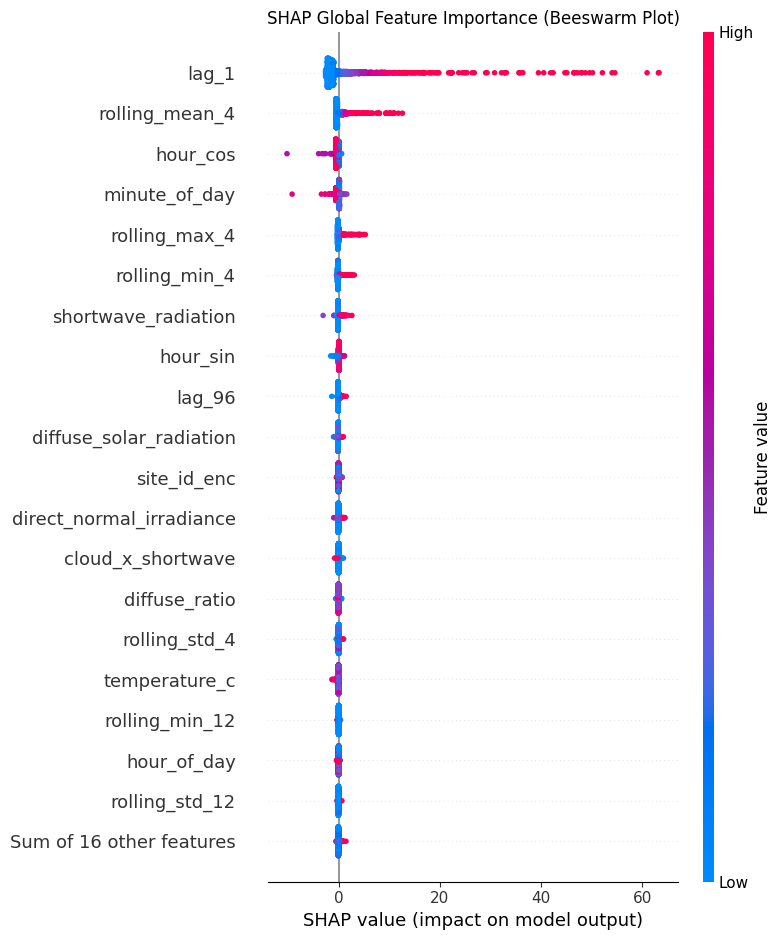

In [3]:
print("Đang khởi tạo TreeExplainer và tính toán giá trị SHAP...")
explainer = shap.TreeExplainer(model)
shap_explanation = explainer(X_sample)
shap_values = shap_explanation.values

# Nếu SHAP trả về 3 chiều, lấy chiều 0
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

print("Tính xong giá trị SHAP. Đang vẽ biểu đồ Beeswarm Global Importance...")
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
plt.title("SHAP Global Feature Importance (Beeswarm Plot)", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Biểu đồ SHAP Dependency Plots cho Top Đặc Trưng

Đang vẽ Dependency Plots cho 4 đặc trưng hàng đầu: ['lag_1', 'rolling_mean_4', 'hour_cos', 'minute_of_day']


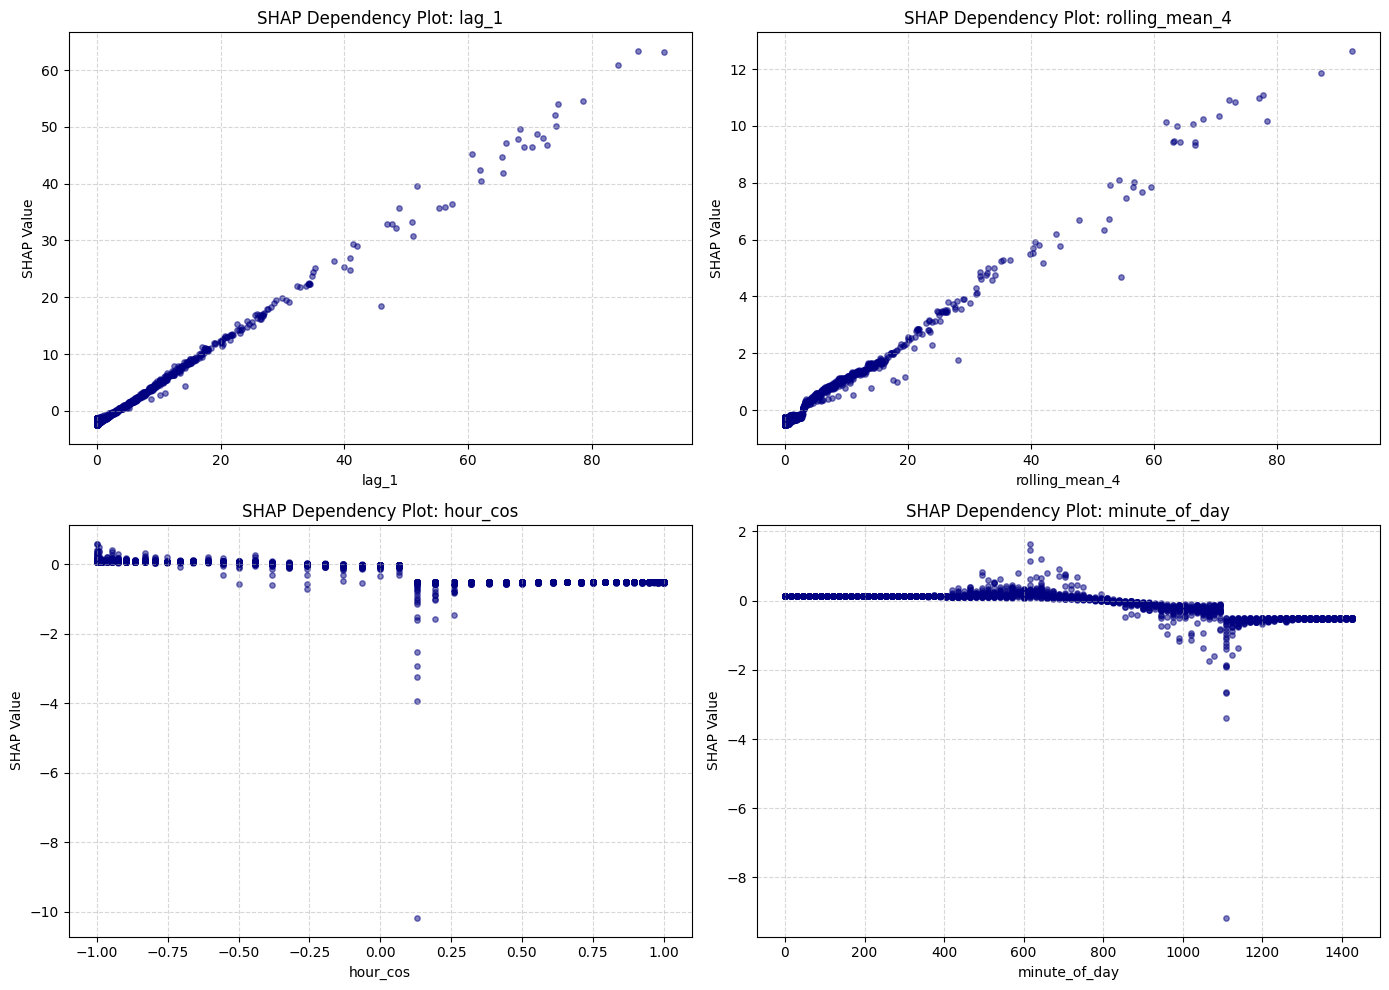

In [4]:
# Tính điểm tầm quan trọng trung bình tuyệt đối
mean_abs_shap = np.abs(shap_values).mean(axis=0)
imp_df = pd.DataFrame({'feature': feat_cols, 'mean_abs_shap': mean_abs_shap})
imp_df = imp_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

top_features = imp_df['feature'].head(4).tolist()

print("Đang vẽ Dependency Plots cho 4 đặc trưng hàng đầu:", top_features)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    feat_idx = feat_cols.index(feat)
    axes[i].scatter(X_sample[feat], shap_values[:, feat_idx], alpha=0.5, c='navy', s=15)
    axes[i].set_title("SHAP Dependency Plot: " + str(feat))
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("SHAP Value")
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Giải thích Local Waterfall cho các điểm sai số lớn nhất

Đang tính sai số dự báo trên tập mẫu để tìm các dòng có sai số lớn nhất...
Đang vẽ biểu đồ Waterfall cho 2 trường hợp sai số lớn nhất...
Giải thích Local - Site: 25 | Thời gian: 2022-03-22 13:00:00 | Sai số: 26.747 kWh


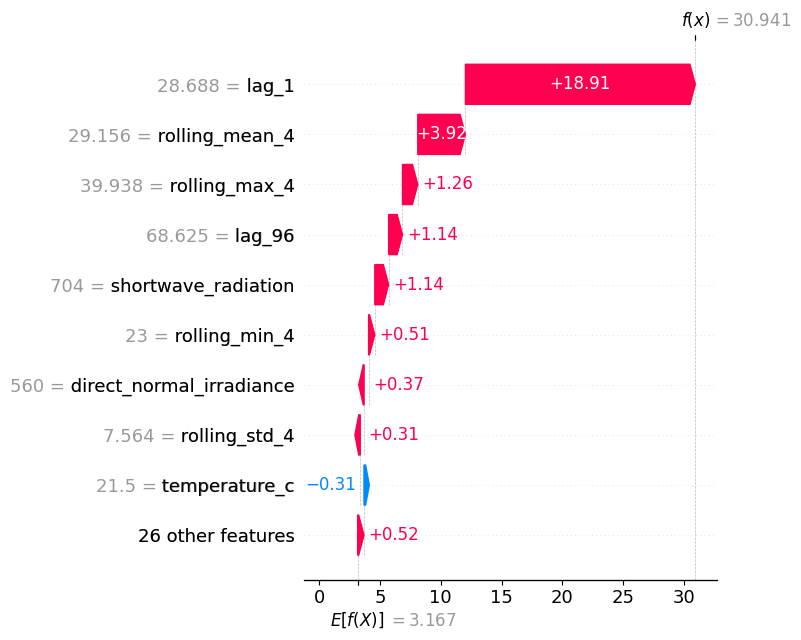

Giải thích Local - Site: 11 | Thời gian: 2022-02-23 14:15:00 | Sai số: 32.19 kWh


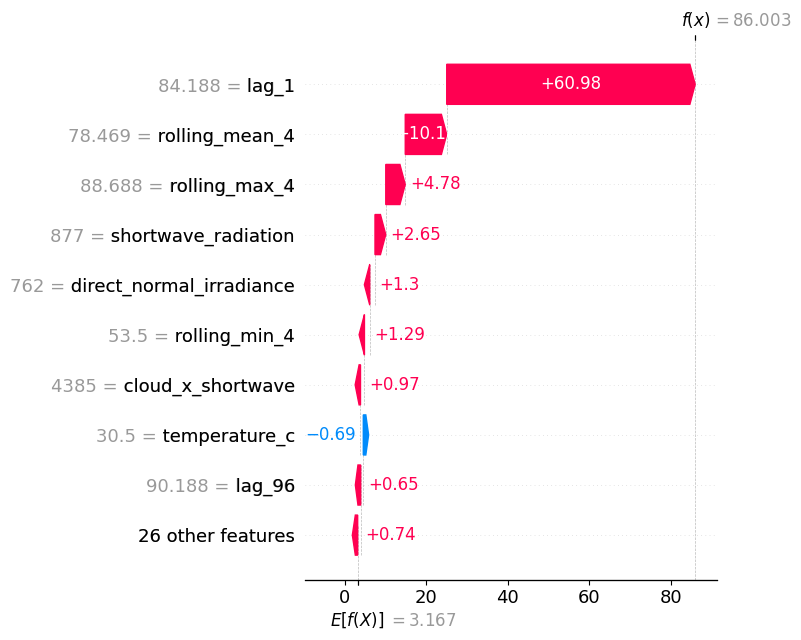

In [5]:
print("Đang tính sai số dự báo trên tập mẫu để tìm các dòng có sai số lớn nhất...")
y_true_sample = test_df.loc[X_sample.index, TARGET_COL].values
y_pred_sample = model.predict(X_sample)
residuals = np.abs(y_true_sample - y_pred_sample)

# Chọn 2 dòng có sai số tuyệt đối lớn nhất
top_error_indices = np.argsort(residuals)[-2:]

print("Đang vẽ biểu đồ Waterfall cho 2 trường hợp sai số lớn nhất...")
for idx in top_error_indices:
    sample_row = X_sample.iloc[idx:idx+1]
    res_val = residuals[idx]
    site_val = test_df.loc[X_sample.index[idx], SITE_COL]
    ts_val = test_df.loc[X_sample.index[idx], TIMESTAMP_COL]

    print("Giải thích Local - Site: " + str(site_val) + " | Thời gian: " + str(ts_val) + " | Sai số: " + str(round(res_val, 3)) + " kWh")
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(shap_explanation[idx], max_display=10, show=False)
    plt.tight_layout()
    plt.show()

## 7. Tổng hợp tầm quan trọng theo Nhóm Đặc Trưng (Feature Group Importance)

=== TỔNG HỢP TẦM QUAN TRỌNG THEO NHÓM ĐẶC TRƯNG ===


,feature_group,mean_abs_shap
0,Lịch sử (Lag/Rolling),4.712685
2,Thời gian,0.732158
3,Thời tiết,0.448157
1,Metadata Trạm,0.069401


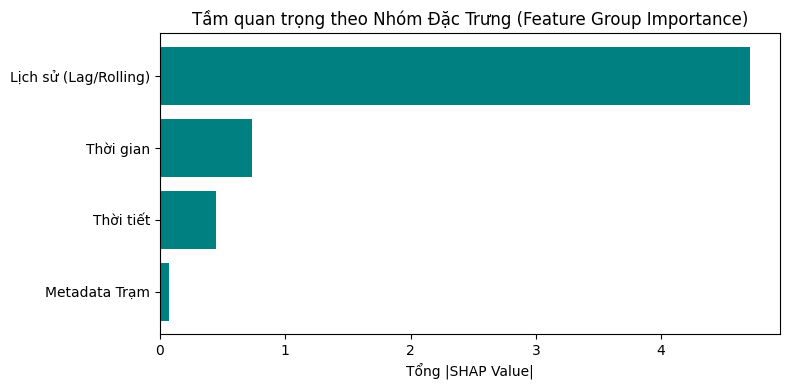

In [6]:
def categorize_feature(name):
    name_lower = name.lower()
    if 'lag' in name_lower or 'rolling' in name_lower:
        return 'Lịch sử (Lag/Rolling)'
    elif any(k in name_lower for k in ['temp', 'radiation', 'cloud', 'irradiance', 'weather', 'diffuse']):
        return 'Thời tiết'
    elif any(k in name_lower for k in ['hour', 'minute', 'month', 'day', 'season', 'doy']):
        return 'Thời gian'
    else:
        return 'Metadata Trạm'

imp_df['feature_group'] = imp_df['feature'].apply(categorize_feature)
group_imp = imp_df.groupby('feature_group')['mean_abs_shap'].sum().reset_index()
group_imp = group_imp.sort_values('mean_abs_shap', ascending=False)

print("=== TỔNG HỢP TẦM QUAN TRỌNG THEO NHÓM ĐẶC TRƯNG ===")
try:
    display(group_imp)
except NameError:
    print(group_imp)

plt.figure(figsize=(8, 4))
plt.barh(group_imp['feature_group'], group_imp['mean_abs_shap'], color='teal')
plt.xlabel("Tổng |SHAP Value|")
plt.title("Tầm quan trọng theo Nhóm Đặc Trưng (Feature Group Importance)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Biểu đồ Plotly tương tác dự báo vs thực tế cho 42 trạm

In [7]:
print("Đang chuẩn bị biểu đồ Plotly tương tác cho 42 trạm quang điện...")

# Nạp file dự báo audit từ notebook 07 nếu có
audit_path = f'{TEST_FINAL_DIR}/prediction_audit.parquet'
if os.path.exists(audit_path):
    audit_df = pd.read_parquet(audit_path)
else:
    # Nếu chưa có, tự chạy dự báo trên test_df
    audit_df = test_df[[SITE_COL, TIMESTAMP_COL, TARGET_COL]].copy()
    audit_df = audit_df.rename(columns={TARGET_COL: 'y_true'})
    audit_df['y_pred'] = model.predict(X_test_full)

sites = sorted(audit_df[SITE_COL].unique())

fig = go.Figure()

# Thêm trace cho từng site (ẩn mặc định, chỉ mở site đầu tiên)
for i, s_id in enumerate(sites):
    site_data = audit_df[audit_df[SITE_COL] == s_id].sort_values(TIMESTAMP_COL).head(300)
    visible = (i == 0)

    fig.add_trace(go.Scatter(
        x=site_data[TIMESTAMP_COL], y=site_data['y_true'],
        mode='lines', name='Thực tế (' + str(s_id) + ')',
        visible=visible, line=dict(color='blue')
    ))
    fig.add_trace(go.Scatter(
        x=site_data[TIMESTAMP_COL], y=site_data['y_pred'],
        mode='lines', name='Dự báo (' + str(s_id) + ')',
        visible=visible, line=dict(color='orange', dash='dash')
    ))

# Tạo Dropdown menu chọn 42 site
buttons = []
for i, s_id in enumerate(sites):
    visible_list = [False] * (len(sites) * 2)
    visible_list[i * 2] = True
    visible_list[i * 2 + 1] = True

    buttons.append(dict(
        label=str(s_id),
        method='update',
        args=[{'visible': visible_list}, {'title': 'Dự Báo vs Thực Tế tại Trạm: ' + str(s_id)}]
    ))

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=0.15, y=1.15, xanchor='left', yanchor='top')],
    title='Dự Báo vs Thực Tế tại Trạm: ' + str(sites[0]),
    xaxis_title='Thời gian',
    yaxis_title='Sản lượng (kWh)',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

Đang chuẩn bị biểu đồ Plotly tương tác cho 42 trạm quang điện...


KeyError: 'y_true'

## 9. Export kết quả SHAP ra Parquet và CSV

In [ ]:
# Export 1: shap_importance.csv
importance_csv_path = f'{OUTPUT_DIR}/shap_importance.csv'
imp_df.to_csv(importance_csv_path, index=False)

# Export 2: shap_values.parquet
shap_df = pd.DataFrame(shap_values, columns=[f'shap_{c}' for c in feat_cols])
meta_df = test_df.loc[X_sample.index, [SITE_COL, TIMESTAMP_COL]].reset_index(drop=True)
shap_export_df = pd.concat([meta_df, shap_df.reset_index(drop=True)], axis=1)

shap_parquet_path = f'{OUTPUT_DIR}/shap_values.parquet'
shap_export_df.to_parquet(shap_parquet_path, index=False)

print("Đã xuất thành công các file kết quả SHAP tại " + OUTPUT_DIR + ":")
print("- " + importance_csv_path)
print("- " + shap_parquet_path)